# Hệ thống Gợi ý Tour Du Lịch — Travela

Notebook này chạy **toàn bộ pipeline** của hệ thống recommendation service:

| Bước | Thành phần | Mô tả |
|------|-----------|-------|
| 1 | **Feature Engineering** | TF-IDF + Cosine Similarity |
| 2 | **Collaborative Filter** | User-based CF (cosine similarity) |
| 3 | **Hybrid Recommender** | CF + Content-based + Popularity |
| 4 | **DeepFM** | LibRecommender (FM + Deep NN) |
| 5 | **Pipeline tổng hợp** | Hybrid tạo candidates → DeepFM re-rank |

**Kiến trúc điểm số:**
```
final_score = 0.7 × Hybrid_score + 0.3 × DeepFM_score
```

## 1. Cài đặt & Import

In [42]:
import sys, os, subprocess

# ── 0. Sửa env vars không hợp lệ trước khi import bất kỳ thứ gì ─────────────
# Một số Jupyter kernel đặt DEBUG=release, pydantic-settings không parse được
_d = os.environ.get('DEBUG', 'false')
if _d.lower() not in ('true', 'false', '1', '0', 'yes', 'no', 'on', 'off'):
    os.environ['DEBUG'] = 'false'

# ── 1. Đặt PROJECT_ROOT ──────────────────────────────────────────────────────
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print(f'Project root: {PROJECT_ROOT}')

# ── 2. Cài các package còn thiếu ─────────────────────────────────────────────
PACKAGES = {
    'motor':             'motor',
    'pymongo':           'pymongo',
    'dotenv':            'python-dotenv',
    'nest_asyncio':      'nest_asyncio',
    'sklearn':           'scikit-learn',
    'numpy':             'numpy',
    'pandas':            'pandas',
    'pydantic_settings': 'pydantic-settings',
}
missing = [pip for imp, pip in PACKAGES.items()
           if subprocess.run([sys.executable, '-c', f'import {imp}'],
                             capture_output=True).returncode != 0]
if missing:
    print(f'Đang cài: {missing}')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + missing, check=True)
    print('Cài xong — vui lòng chạy lại cell này.')
else:
    print('Tất cả packages OK.')

# ── 3. Import ─────────────────────────────────────────────────────────────────
import asyncio, warnings, logging
import numpy as np
import pandas as pd
import nest_asyncio
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
nest_asyncio.apply()

load_dotenv(os.path.join(PROJECT_ROOT, '.env'), override=False)
print('Import OK — ready!')

Project root: /Users/qhung/KLTN/recommendation-service
Tất cả packages OK.
Import OK — ready!


## 2. Kết nối MongoDB & Khởi tạo Services

In [43]:
import os
# Ensure DEBUG is a valid boolean string before pydantic-settings reads it
_debug_raw = os.environ.get('DEBUG', 'false')
if _debug_raw.lower() not in ('true', 'false', '1', '0', 'yes', 'no', 'on', 'off'):
    os.environ['DEBUG'] = 'false'

from app.config.database import connect_to_mongo, get_database
from app.config.settings import settings

async def setup_db():
    await connect_to_mongo(settings.MONGODB_URI, settings.DB_NAME)
    return get_database()

db = asyncio.run(setup_db())
print(f'Đã kết nối MongoDB: {settings.DB_NAME}')

Đã kết nối MongoDB: travela


## 3. Load dữ liệu từ MongoDB

In [44]:
from app.services.tour_service import TourService

tour_service = TourService()

async def load_data():
    tours    = await tour_service.get_all_tours(include_departures=False)
    bookings = await tour_service.get_all_bookings()
    reviews  = await tour_service.get_all_reviews()
    return tours, bookings, reviews

tours, bookings, reviews = asyncio.run(load_data())

print(f'Tours:    {len(tours)}')
print(f'Bookings: {len(bookings)}')
print(f'Reviews:  {len(reviews)}')

# Thống kê tổng quan
df_tours = pd.DataFrame([{
    'id': t['_id'],
    'title': t.get('title','')[:40],
    'destination': t.get('destination',''),
    'priceAdult': t.get('priceAdult', 0),
    'time': t.get('time', ''),
} for t in tours])

print(f'\nDestinations ({df_tours["destination"].nunique()}):')
print(df_tours['destination'].value_counts().head(10).to_string())

Tours:    43
Bookings: 334
Reviews:  309

Destinations (29):
destination
Lào Cai       3
Tây Ninh      2
Miền Tây      2
Miền Trung    2
Quảng Bình    2
Hà Giang      2
Cần Thơ       2
Bình Thuận    2
Khánh Hòa     2
Đà Nẵng       2


## 4. Feature Engineering — TF-IDF + Cosine Similarity

In [45]:
from app.services.feature_engineering import TourFeatureExtractor, TourSimilarityCalculator

# Fit feature extractor trên toàn bộ tours
feature_extractor = TourFeatureExtractor()
feature_extractor.fit(tours)

# Xây dựng similarity matrix
sim_calc = TourSimilarityCalculator(feature_extractor)
sim_calc.build_similarity_matrix(tours)

print(f'Feature dim: {feature_extractor.feature_dim}')
print(f'Similarity matrix: {sim_calc.similarity_matrix.shape}')

# Demo: Top-3 tour tương tự cho tour đầu tiên
sample_tour = tours[0]
similar = sim_calc.get_similar_tours(sample_tour['_id'], top_k=3)
print(f'\nTop-3 tour tương tự với "{sample_tour.get("title","")[:30]}":')
tour_map = {t['_id']: t for t in tours}
for tid, score in similar:
    t = tour_map.get(tid, {})
    print(f'  [{score:.3f}] {t.get("destination","?"):15} | {t.get("title","")[:35]}')

Feature dim: 81
Similarity matrix: (43, 43)

Top-3 tour tương tự với "Du lịch Hạ Long - Vịnh Kỳ Quan":
  [0.354] Ninh Bình       | Ninh Bình - Tràng An Cổ Kính 2N1Đ
  [0.290] Quảng Bình      | Sơn Đoòng - Adventure Tour
  [0.229] Miền Trung      | Đà Nẵng - Quảng Bình - Động Phong N


## 5. Collaborative Filter — User-based CF

In [46]:
from app.services.collaborative import CollaborativeFilter
from app.services.content_based import ContentBasedFilter

async def build_cf():
    cf = CollaborativeFilter()
    await cf.build_model(bookings, reviews)
    return cf

cf = asyncio.run(build_cf())
cb = ContentBasedFilter(feature_extractor, sim_calc)

n_users = len(cf.user_ratings)
n_tours = len(cf.all_tour_ids)
total_ratings = sum(len(v) for v in cf.user_ratings.values())
density = total_ratings / (n_users * n_tours) * 100 if n_users * n_tours > 0 else 0

print(f'CF model: {n_users} users, {n_tours} tours')
print(f'Total ratings: {total_ratings}')
print(f'User-tour density: {density:.2f}%')

CF model: 69 users, 46 tours
Total ratings: 402
User-tour density: 12.67%


## 6. Hybrid Recommender — CF + Content-based + Popularity

**Dynamic weights theo mức độ hoạt động của user:**

| User level | CF | Content-based | Popularity |
|-----------|-----|---------------|------------|
| Cold (0 bookings) | 0% | 30% | 70% |
| New (1-2) | 20% | 30% | 50% |
| Regular (3-10) | 40% | 40% | 20% |
| Active (>10) | 50% | 40% | 10% |

In [47]:
from app.services.hybrid_recommender import HybridRecommender

async def build_hybrid():
    hybrid = HybridRecommender(cf, cb, tour_service)
    await hybrid.initialize()
    return hybrid

hybrid = asyncio.run(build_hybrid())
print(f'Hybrid initialized: {len(hybrid.popularity_scores)} tour popularity scores')
print()

# Demo: Gợi ý cho 3 user khác nhau
TEST_USERS = [
    '690389ed1796c209816e39be',
    '68d98f3b9fbcf0e9f2b1c0c8',
    '68e7de21ee219fe223e3a1d9',
]

async def demo_hybrid():
    for uid in TEST_USERS:
        recs = await hybrid.get_homepage_recommendations(uid, limit=4)
        print(f'User {uid[:8]}... → {len(recs)} gợi ý:')
        for t in recs:
            print(f'  {t.get("destination","?"):18} | {t.get("title","")[:35]}')
        print()

asyncio.run(demo_hybrid())

Hybrid initialized: 43 tour popularity scores

User 690389ed... → 4 gợi ý:
  Cần Thơ            | Cần Thơ - Miền Tây Sông Nước 2N1Đ
  Miền Trung         | Quy Nhơn - Tuy Hòa
  Tây Nguyên         | Buôn Ma Thuột - Pleiku - Măng Đen
  Bà Rịa - Vũng Tàu  | Côn Đảo - Hoang Đảo Huyền Thoại 3N2

User 68d98f3b... → 4 gợi ý:
  Lào Cai            | Sapa - Fansipan - Bản Cát Cát (Trải
  Tây Nguyên         | Buôn Ma Thuột - Pleiku - Măng Đen
  Bình Thuận         | Mũi Né - Thiên Đường Cát 3N2Đ
  Bà Rịa - Vũng Tàu  | Côn Đảo - Hoang Đảo Huyền Thoại 3N2

User 68e7de21... → 4 gợi ý:
  Lào Cai            | Sapa - Fansipan - Bản Cát Cát (Trải
  Bình Định          | Quy Nhơn - Kỳ Co - Eo Gió (Luxury)
  Vũng Tàu           | Vũng Tàu - Biển nghỉ dưỡng
  Miền Trung         | Quy Nhơn - Tuy Hòa



## 7. DeepFM — LibRecommender (FM + Deep Neural Network)

**Features:**
- `destination` (sparse, item)
- `price_bucket` (sparse, item) — 10 buckets theo quantile
- `duration_bucket` (sparse, item) — số ngày tour

**Label sources:**
- Reviews: rating 1–5
- Bookings: completed=5, confirmed=4, pending=3
- Interactions: bookmark=4, share=3.5, click=2, view=1

In [48]:
from app.services.deepfm_model import DeepFMRecommender

deepfm = DeepFMRecommender(model_path=os.path.join(PROJECT_ROOT, 'models/deepfm_libreco'))

async def init_deepfm():
    await deepfm.initialize(db)

asyncio.run(init_deepfm())

print(f'DeepFM status    : is_trained={deepfm.is_trained}')
print(f'Users encoded    : {len(deepfm.user_encoder)}')
print(f'Tours encoded    : {len(deepfm.tour_encoder)}')
print(f'Destinations     : {len(deepfm.dest_encoder)}')
print(f'Price boundaries : {[f"{p/1e6:.1f}M" for p in deepfm.price_boundaries]}')
print(f'Last update      : {deepfm.last_update}')

total params: 24,024 | embedding params: 2,946 | network params: 21,078
DeepFM status    : is_trained=True
Users encoded    : 71
Tours encoded    : 42
Destinations     : 29
Price boundaries : ['1.0M', '2.0M', '2.4M', '3.2M', '3.5M', '3.8M', '4.2M', '4.8M', '5.5M']
Last update      : 2026-05-23 15:42:05.340812


In [49]:
# Demo: recommend_user() cho user đã biết
async def demo_deepfm():
    user_id = TEST_USERS[0]
    recs = await deepfm.recommend(user_id, n_rec=6)
    print(f'DeepFM recommend cho user {user_id[:8]}... ({len(recs)} tours):')
    for rank, tid in enumerate(recs, 1):
        t = tour_map.get(tid, {})
        print(f'  #{rank} {t.get("destination","?"):18} | {t.get("title","")[:35]}')
    print()

    # Predict score cho 1 cặp user-tour
    all_ids = [t['_id'] for t in tours]
    scores = await deepfm.predict(user_id, all_ids[:5], db)
    print('Predict scores (5 tours đầu):')
    for tid, score in scores[:5]:
        t = tour_map.get(tid, {})
        print(f'  [{score:.4f}] {t.get("title","")[:40]}')

asyncio.run(demo_deepfm())

DeepFM recommend cho user 690389ed... (6 tours):
  #1 Lào Cai            | Sapa - Fansipan - Bản Cát Cát (Trải
  #2 Bình Định          | Quy Nhơn - Kỳ Co - Eo Gió (Luxury)
  #3 Bình Thuận         | Khám phá Sapa Mùa Sương Mù 3N2Đ - C
  #4 Đà Nẵng            | Đà Nẵng - Hội An - Bà Nà Hills
  #5 Nghệ An            | Vinh - KDT Kim Liên - Đồi Chè Thanh
  #6 Vũng Tàu           | Vũng Tàu - Biển nghỉ dưỡng

Predict scores (5 tours đầu):
  [0.5510] Du lịch Hạ Long - Vịnh Kỳ Quan 3N2Đ
  [0.4982] Hà Giang - Đỉnh Trời Mây 4N3Đ
  [0.5350] Cát Bà - Đảo Ngọc Xanh 3N2Đ
  [0.4956] Đà Lạt - Thành Phố Ngàn Hoa 3N2Đ
  [0.5251] Huế - Cố Đô Ngàn Năm 3N2Đ


## 8. Pipeline Tổng Hợp — Hybrid Primary + DeepFM Re-rank

```
User request
    ↓
HybridRecommender → candidate pool (4× limit)
    ↓
DeepFM.predict() → re-score candidates
    ↓
Blend: 70% Hybrid + 30% DeepFM
    ↓
Diversity filter (max 2 tour/destination)
    ↓
Top-N kết quả
```

In [50]:
from app.services.deepfm_recommender import DeepFMRecommenderService

async def build_pipeline():
    svc = DeepFMRecommenderService(
        tour_service=tour_service,
        model_path=os.path.join(PROJECT_ROOT, 'models/deepfm_libreco'),
        hybrid_recommender=hybrid,
    )
    await svc.initialize(db)
    return svc

pipeline = asyncio.run(build_pipeline())
print(f'Pipeline ready: is_initialized={pipeline.is_initialized}')

total params: 24,024 | embedding params: 2,946 | network params: 21,078
Pipeline ready: is_initialized=True


In [51]:
# Demo pipeline cho 3 user
async def demo_pipeline():
    print('=' * 65)
    print('PIPELINE: Hybrid (70%) + DeepFM Re-rank (30%)')
    print('=' * 65)

    for uid in TEST_USERS:
        recs = await pipeline.get_homepage_recommendations(uid, limit=4)
        print(f'\nUser {uid[:8]}... ({len(recs)} gợi ý):')
        print(f'  {"Score":>6}  {"Destination":18}  {"Tour"}')
        print(f'  {"─"*6}  {"─"*18}  {"─"*35}')
        for r in recs:
            score = r.get('_score', 0)
            dest  = r.get('destination', '?')
            title = r.get('title', '?')[:35]
            print(f'  {score:6.3f}  {dest:18}  {title}')

    print()
    print('=== Anonymous user (no userId) ===')
    popular = await pipeline._get_popular_tours(4)
    for r in popular:
        print(f'  [{r.get("_score",0):.3f}] {r.get("destination","?"):18} | {r.get("title","")[:35]}')

asyncio.run(demo_pipeline())

PIPELINE: Hybrid (70%) + DeepFM Re-rank (30%)

User 690389ed... (4 gợi ý):
   Score  Destination         Tour
  ──────  ──────────────────  ───────────────────────────────────
   0.650  Tây Nguyên          Buôn Ma Thuột - Pleiku - Măng Đen
   0.599  Bình Thuận          Khám phá Sapa Mùa Sương Mù 3N2Đ - C
   0.591  Đà Nẵng             Đà Nẵng - Hội An - Bà Nà Hills
   0.562  Cần Thơ             Cần Thơ - Miền Tây Sông Nước 2N1Đ

User 68d98f3b... (4 gợi ý):
   Score  Destination         Tour
  ──────  ──────────────────  ───────────────────────────────────
   0.697  Tây Nguyên          Buôn Ma Thuột - Pleiku - Măng Đen
   0.650  Lào Cai             Sapa - Fansipan - Bản Cát Cát (Trải
   0.587  Cần Thơ             Cần Thơ - Miền Tây Sông Nước 2N1Đ
   0.501  Đông Bắc            Cao Bằng - Thác Bản Giốc - Ba Bể

User 68e7de21... (4 gợi ý):
   Score  Destination         Tour
  ──────  ──────────────────  ───────────────────────────────────
   0.788  Tây Nguyên          Buôn Ma Thuột - Pleiku

## 9. So sánh 3 Model

In [52]:
async def compare_models(user_id, limit=4):
    # Popularity
    pop_tours = await tour_service.get_popular_tours(limit)
    pop_titles = [t.get('title','')[:30] for t in pop_tours]

    # Hybrid only
    hybrid_recs = await hybrid.get_homepage_recommendations(user_id, limit)
    hybrid_titles = [t.get('title','')[:30] for t in hybrid_recs]

    # Hybrid + DeepFM
    pipeline_recs = await pipeline.get_homepage_recommendations(user_id, limit)
    pipeline_titles = [t.get('title','')[:30] for t in pipeline_recs]

    # Hiển thị
    print(f'So sánh gợi ý cho user {user_id[:8]}...')
    print(f'{"Rank":>4}  {"Popularity":32}  {"Hybrid":32}  {"Hybrid+DeepFM":32}')
    print(f'  {"─"*4}  {"─"*32}  {"─"*32}  {"─"*32}')
    for i in range(limit):
        p = pop_titles[i] if i < len(pop_titles) else '—'
        h = hybrid_titles[i] if i < len(hybrid_titles) else '—'
        d = pipeline_titles[i] if i < len(pipeline_titles) else '—'
        print(f'  #{i+1:2d}  {p:32}  {h:32}  {d:32}')

asyncio.run(compare_models(TEST_USERS[0], limit=4))

So sánh gợi ý cho user 690389ed...
Rank  Popularity                        Hybrid                            Hybrid+DeepFM                   
  ────  ────────────────────────────────  ────────────────────────────────  ────────────────────────────────
  # 1  Quy Nhơn - Tuy Hòa                Cần Thơ - Miền Tây Sông Nước 2    Buôn Ma Thuột - Pleiku - Măng   
  # 2  Buôn Ma Thuột - Pleiku - Măng     Quy Nhơn - Tuy Hòa                Khám phá Sapa Mùa Sương Mù 3N2  
  # 3  Cần Thơ - Miền Tây Sông Nước 2    Buôn Ma Thuột - Pleiku - Măng     Đà Nẵng - Hội An - Bà Nà Hills  
  # 4  Sapa - Fansipan - Bản Cát Cát     Côn Đảo - Hoang Đảo Huyền Thoạ    Cần Thơ - Miền Tây Sông Nước 2  


## 10. Biểu đồ & Đánh giá Hệ thống

| Biểu đồ | Nội dung |
|---------|---------|
| **10.1 Tổng quan dữ liệu** | Tour theo điểm đến, phân phối rating, booking status, user activity, price bucket, duration |
| **10.2 So sánh 3 model** | Coverage · Diversity · Personalization cho Popularity / Hybrid / Hybrid+DeepFM |

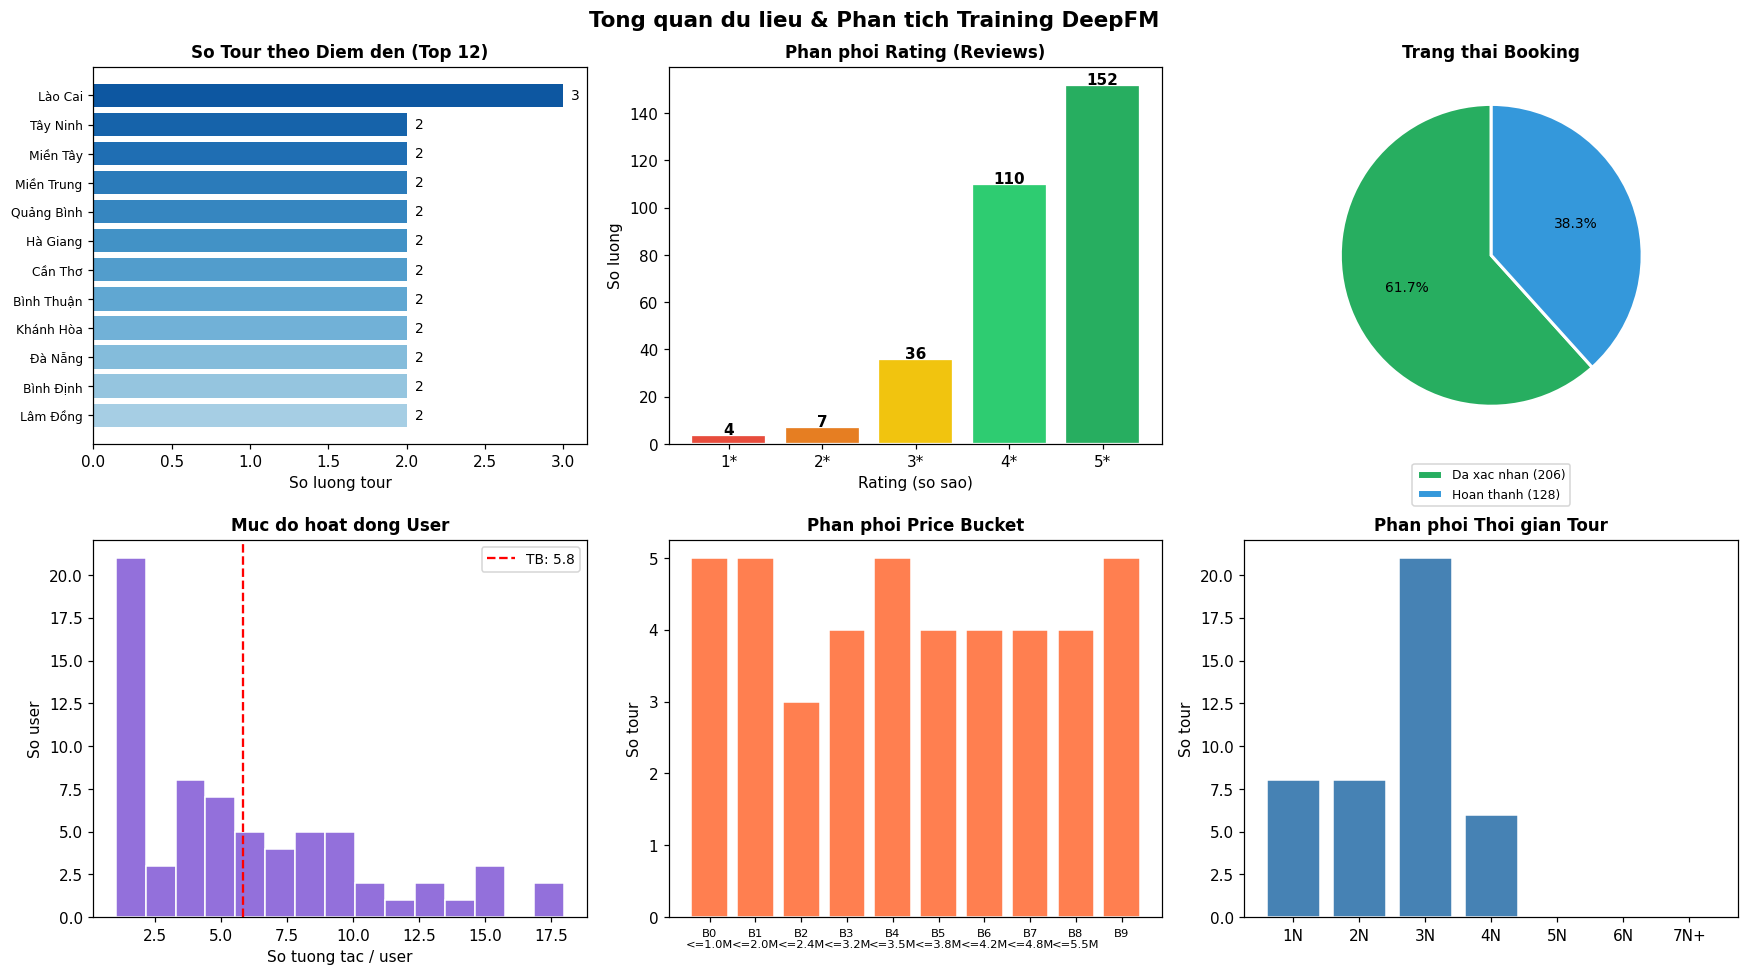


Thong ke du lieu training:
  Users co tuong tac : 69
  Tours co tuong tac : 46
  Total interactions  : 402
  Matrix density      : 13.48%  (402/71x42)
  DeepFM user encode  : 71 users  |  tour encode: 42 tours
  Model last update   : 2026-05-23 15:42:05.340812


In [53]:
import re
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Tong quan du lieu & Phan tich Training DeepFM', fontsize=14, fontweight='bold')

# ── [0,0] Tour theo diem den (top 12) ────────────────────────────────────────
dest_counts = df_tours['destination'].value_counts().head(12)
colors_bar  = plt.cm.Blues(np.linspace(0.35, 0.85, len(dest_counts)))
axes[0,0].barh(range(len(dest_counts)), dest_counts.values[::-1], color=colors_bar)
axes[0,0].set_yticks(range(len(dest_counts)))
axes[0,0].set_yticklabels(dest_counts.index[::-1], fontsize=8)
axes[0,0].set_title('So Tour theo Diem den (Top 12)', fontweight='bold')
axes[0,0].set_xlabel('So luong tour')
for i, val in enumerate(dest_counts.values[::-1]):
    axes[0,0].text(val + 0.05, i, str(val), va='center', fontsize=9)

# ── [0,1] Phan phoi Rating ───────────────────────────────────────────────────
ratings = [r.get('rating', 0) for r in reviews if r.get('rating')]
rating_counts = [ratings.count(i) for i in range(1, 6)]
star_colors   = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
bars = axes[0,1].bar(range(1, 6), rating_counts, color=star_colors,
                     edgecolor='white', linewidth=1.5)
axes[0,1].set_title('Phan phoi Rating (Reviews)', fontweight='bold')
axes[0,1].set_xlabel('Rating (so sao)')
axes[0,1].set_ylabel('So luong')
axes[0,1].set_xticks(range(1, 6))
axes[0,1].set_xticklabels(['1*','2*','3*','4*','5*'])
for bar, val in zip(bars, rating_counts):
    if val > 0:
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                       str(val), ha='center', fontweight='bold')

# ── [0,2] Trang thai Booking ─────────────────────────────────────────────────
status_labels = {'completed':'Hoan thanh','confirmed':'Da xac nhan',
                 'pending':'Cho xu ly','cancelled':'Da huy'}
status_counts = {}
for b in bookings:
    s = b.get('bookingStatus','other')
    k = status_labels.get(s, s)
    status_counts[k] = status_counts.get(k, 0) + 1
pie_colors = ['#27ae60','#3498db','#e67e22','#e74c3c','#95a5a6']
if status_counts:
    wedges, _, autotexts = axes[0,2].pie(
        status_counts.values(), autopct='%1.1f%%',
        colors=pie_colors[:len(status_counts)],
        startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
    for at in autotexts:
        at.set_fontsize(9)
    axes[0,2].legend(wedges, [f'{k} ({v})' for k,v in status_counts.items()],
                     loc='lower center', bbox_to_anchor=(0.5,-0.18), fontsize=8)
axes[0,2].set_title('Trang thai Booking', fontweight='bold')

# ── [1,0] Muc do hoat dong User ─────────────────────────────────────────────
user_activity = sorted(len(v) for v in cf.user_ratings.values())
axes[1,0].hist(user_activity, bins=min(15, len(set(user_activity))),
               color='mediumpurple', edgecolor='white', linewidth=1)
avg_act = np.mean(user_activity)
axes[1,0].axvline(avg_act, color='red', linestyle='--', linewidth=1.5,
                  label=f'TB: {avg_act:.1f}')
axes[1,0].set_title('Muc do hoat dong User', fontweight='bold')
axes[1,0].set_xlabel('So tuong tac / user')
axes[1,0].set_ylabel('So user')
axes[1,0].legend(fontsize=9)

# ── [1,1] Price bucket ───────────────────────────────────────────────────────
if deepfm.price_boundaries:
    prices  = [t.get('priceAdult', 0) for t in tours if t.get('priceAdult', 0) > 0]
    buckets = [deepfm._price_bucket(p) for p in prices]
    b_cnts  = [buckets.count(i) for i in range(10)]
    b_lbls  = [f'B{i}\n<={deepfm.price_boundaries[i]/1e6:.1f}M'
               if i < len(deepfm.price_boundaries) else f'B{i}' for i in range(10)]
    axes[1,1].bar(range(10), b_cnts, color='coral', edgecolor='white')
    axes[1,1].set_xticks(range(10))
    axes[1,1].set_xticklabels(b_lbls, fontsize=7.5)
    axes[1,1].set_title('Phan phoi Price Bucket', fontweight='bold')
    axes[1,1].set_ylabel('So tour')

# ── [1,2] Duration bucket ────────────────────────────────────────────────────
def _days(s):
    if not s: return 1
    m = re.search(r'(\d+)\s*ng', s.lower())
    return int(m.group(1)) if m else (int(re.search(r'(\d+)',s).group(1)) if re.search(r'(\d+)',s) else 1)

durations  = [min(max(_days(t.get('time','')) - 1, 0), 6) for t in tours]
dur_counts = [durations.count(i) for i in range(7)]
dur_labels = ['1N','2N','3N','4N','5N','6N','7N+']
axes[1,2].bar(range(7), dur_counts, color='steelblue', edgecolor='white')
axes[1,2].set_xticks(range(7))
axes[1,2].set_xticklabels(dur_labels)
axes[1,2].set_title('Phan phoi Thoi gian Tour', fontweight='bold')
axes[1,2].set_ylabel('So tour')

plt.tight_layout()
plt.savefig('charts_data_overview.png', bbox_inches='tight', dpi=130)
plt.show()

# Thong ke training
n_u  = len(deepfm.user_encoder)
n_t  = len(deepfm.tour_encoder)
n_samples = sum(len(v) for v in cf.user_ratings.values())
density   = n_samples / max(n_u * n_t, 1) * 100
print(f'\nThong ke du lieu training:')
print(f'  Users co tuong tac : {len(cf.user_ratings)}')
print(f'  Tours co tuong tac : {len(cf.all_tour_ids)}')
print(f'  Total interactions  : {n_samples}')
print(f'  Matrix density      : {density:.2f}%  ({n_samples}/{n_u}x{n_t})')
print(f'  DeepFM user encode  : {n_u} users  |  tour encode: {n_t} tours')
print(f'  Model last update   : {deepfm.last_update}')

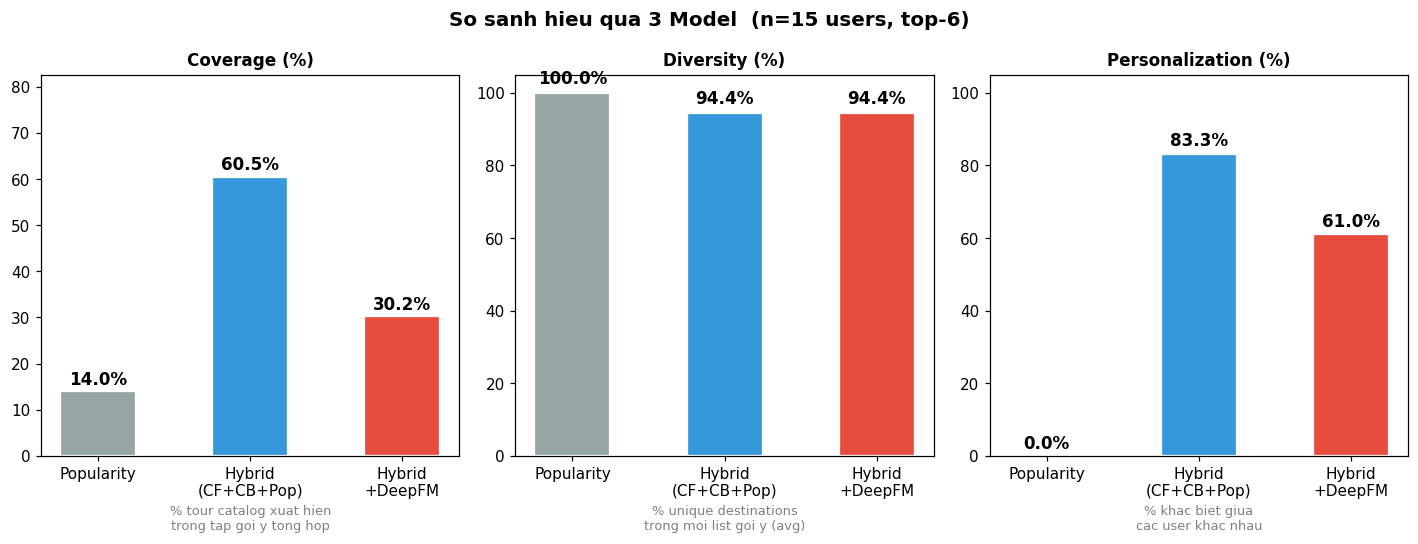


Model                    Coverage  Diversity    Personal.
----------------------------------------------------------
Popularity                  14.0%      100.0%         0.0%
Hybrid (CF+CB+Pop)          60.5%       94.4%        83.3%
Hybrid +DeepFM              30.2%       94.4%        61.0%

Coverage      : % tour catalog duoc goi y it nhat 1 lan
Diversity     : do da dang diem den trong moi list
Personalization: muc do khac biet giua cac user (cao = tot)


In [54]:
import asyncio
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 11})

EVAL_LIMIT  = 6
eval_users  = list(cf.user_ratings.keys())[:15]
tour_dest   = {t['_id']: t.get('destination', 'Unknown') for t in tours}
all_ids_set = set(t['_id'] for t in tours)

# ── Thu thập gợi ý từ 3 model ─────────────────────────────────────────────────
async def collect_recs(users, limit):
    pop, hyb, pip = {}, {}, {}
    for uid in users:
        p = await tour_service.get_popular_tours(limit)
        pop[uid] = [t['_id'] for t in p]
        h = await hybrid.get_homepage_recommendations(uid, limit)
        hyb[uid] = [t['_id'] for t in h]
        d = await pipeline.get_homepage_recommendations(uid, limit)
        pip[uid] = [t['_id'] for t in d]
    return {'Popularity': pop, 'Hybrid\n(CF+CB+Pop)': hyb, 'Hybrid\n+DeepFM': pip}

all_recs = asyncio.run(collect_recs(eval_users, EVAL_LIMIT))

# ── Tính metrics ──────────────────────────────────────────────────────────────
def compute_metrics(recs_per_user):
    all_rec  = set(tid for lst in recs_per_user.values() for tid in lst)
    coverage = len(all_rec) / max(len(all_ids_set), 1) * 100

    divs = []
    for tids in recs_per_user.values():
        dests = [tour_dest.get(t, 'Unknown') for t in tids]
        divs.append(len(set(dests)) / max(len(dests), 1) * 100)
    diversity = np.mean(divs) if divs else 0.0

    users = list(recs_per_user.keys())
    dists = []
    for i in range(len(users)):
        for j in range(i + 1, len(users)):
            s1, s2 = set(recs_per_user[users[i]]), set(recs_per_user[users[j]])
            u = s1 | s2
            if u:
                dists.append(1 - len(s1 & s2) / len(u))
    personalization = np.mean(dists) * 100 if dists else 0.0
    return coverage, diversity, personalization

metrics_data = {name: compute_metrics(recs) for name, recs in all_recs.items()}

# ── Vẽ biểu đồ ───────────────────────────────────────────────────────────────
model_names  = list(all_recs.keys())
model_colors = ['#95a5a6', '#3498db', '#e74c3c']
metric_info  = [
    ('Coverage (%)',        '% tour catalog xuat hien\ntrong tap goi y tong hop'),
    ('Diversity (%)',       '% unique destinations\ntrong moi list goi y (avg)'),
    ('Personalization (%)', '% khac biet giua\ncac user khac nhau'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle(f'So sanh hieu qua 3 Model  (n={len(eval_users)} users, top-{EVAL_LIMIT})',
             fontsize=13, fontweight='bold')

for ax_i, (label, desc) in enumerate(metric_info):
    vals = [metrics_data[m][ax_i] for m in model_names]
    bars = axes[ax_i].bar(model_names, vals, color=model_colors,
                          edgecolor='white', linewidth=1.5, width=0.5)
    axes[ax_i].set_title(label, fontweight='bold')
    axes[ax_i].set_xlabel(desc, fontsize=8.5, color='gray')
    axes[ax_i].set_ylim(0, min(max(vals) * 1.35 + 1, 105))
    for bar, val in zip(bars, vals):
        axes[ax_i].text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max(vals) * 0.025,
                        f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('charts_model_comparison.png', bbox_inches='tight', dpi=130)
plt.show()

print(f'\n{"Model":22} {"Coverage":>10} {"Diversity":>10} {"Personal.":>12}')
print('-' * 58)
for name in model_names:
    c, d, p = metrics_data[name]
    print(f'{name.replace(chr(10)," "):22} {c:>9.1f}%  {d:>9.1f}%  {p:>10.1f}%')
print()
print('Coverage      : % tour catalog duoc goi y it nhat 1 lan')
print('Diversity     : do da dang diem den trong moi list')
print('Personalization: muc do khac biet giua cac user (cao = tot)')

## 11. Retrain DeepFM

Chạy cell này để retrain model từ đầu với dữ liệu hiện tại.

In [55]:
async def retrain(epochs=20):
    print(f'Bắt đầu retrain DeepFM ({epochs} epochs)...')
    result = await deepfm.train(db, epochs=epochs)
    print('\nKết quả:')
    for k, v in result.items():
        print(f'  {k}: {v}')
    return result

# Uncomment để retrain:
# result = asyncio.run(retrain(epochs=20))

### 11.1 Learning Curves — Loss, ROC-AUC, Precision/Recall, NDCG

Cell này tự động retrain DeepFM nếu chưa có `training_history`, sau đó vẽ **4 biểu đồ**:

| Chart | Ý nghĩa |
|-------|---------|
| **Training Loss** | Đường loss giảm dần → model đang học. Đỏ nét đứt = điểm hội tụ |
| **ROC-AUC** | Khả năng phân biệt tour tốt/xấu cho user. > 0.5 = tốt hơn random |
| **Precision & Recall @10** | Độ chính xác & độ bao phủ trong top-10 gợi ý |
| **NDCG@10** | Chất lượng xếp hạng — tour phù hợp ở vị trí cao hơn được điểm cao hơn |

In [56]:
import io, sys, re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ══════════════════════════════════════════════════════════════════════════════
# Retrain với stdout capture → lấy per-epoch metrics
# (nếu model đã load từ file có history thì bỏ qua bước retrain)
# ══════════════════════════════════════════════════════════════════════════════

async def retrain_capture(epochs=20):
    buf = io.StringIO()
    old = sys.stdout
    sys.stdout = buf
    try:
        await deepfm.train(db, epochs=epochs)
    finally:
        sys.stdout = old
    raw = buf.getvalue()
    print(raw, end='')
    return raw

if not deepfm.training_history:
    print('Chua co training history — dang retrain (20 epochs)...')
    raw = asyncio.run(retrain_capture(epochs=20))
    deepfm.training_history = deepfm._parse_training_output(raw)
else:
    print(f'Su dung training history san co: {len(deepfm.training_history)} epochs')

history = deepfm.training_history
print(f'Parsed {len(history)} epochs, metrics: {list(history[0].keys()) if history else []}')

# ── Vẽ learning curves ────────────────────────────────────────────────────────
def plot_learning_curves(history):
    if not history:
        print('Khong co du lieu training history.')
        return

    epochs = [h['epoch'] for h in history]
    losses = [h.get('loss') for h in history]
    aucs   = [h.get('roc_auc') for h in history]
    precs  = [h.get('precision') for h in history]
    recs   = [h.get('recall') for h in history]
    ndcgs  = [h.get('ndcg') for h in history]

    has_eval = any(v is not None for v in aucs)
    ncols = 4 if has_eval else 1
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4.5))
    if ncols == 1:
        axes = [axes]
    fig.suptitle(f'Ket qua Training DeepFM — Learning Curves ({epochs[-1]} epochs)',
                 fontsize=13, fontweight='bold')

    # ── Loss curve ───────────────────────────────────────────────────────────
    ax = axes[0]
    if any(v is not None for v in losses):
        valid_loss = [(e, v) for e, v in zip(epochs, losses) if v is not None]
        xe, ye = zip(*valid_loss)
        ax.plot(xe, ye, 'b-o', markersize=4, linewidth=2, label='Train loss')
        ax.set_title('Training Loss', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Cross-entropy loss')
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

        # Diem hoi tu: loss giam < 0.001 giua 2 epoch lien tiep
        diffs = [ye[i] - ye[i+1] for i in range(len(ye)-1)]
        conv_i = next((i for i, d in enumerate(diffs) if abs(d) < 0.001), len(xe)-1)
        ax.axvline(xe[conv_i], color='red', linestyle='--', alpha=0.6,
                   label=f'Hoi tu ~epoch {xe[conv_i]}')
        ax.legend(fontsize=9)
    else:
        ax.text(0.5, 0.5, 'Khong co du lieu loss', ha='center', va='center',
                transform=ax.transAxes, color='gray')

    if has_eval:
        # ── ROC-AUC ──────────────────────────────────────────────────────────
        ax = axes[1]
        valid_auc = [(e, v) for e, v in zip(epochs, aucs) if v is not None]
        if valid_auc:
            xe, ye = zip(*valid_auc)
            ax.plot(xe, ye, 'g-o', markersize=4, linewidth=2)
            ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
            best_auc = max(ye)
            ax.axhline(best_auc, color='green', linestyle=':', alpha=0.7,
                       label=f'Best: {best_auc:.4f}')
            ax.set_title('ROC-AUC (Eval)', fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('AUC')
            ax.set_ylim(max(0.4, min(ye) - 0.05), min(1.0, max(ye) + 0.05))
            ax.grid(True, alpha=0.3)
            ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
            ax.legend(fontsize=9)

        # ── Precision & Recall ────────────────────────────────────────────────
        ax = axes[2]
        plotted = False
        for vals, label, color, marker in [
            (precs, 'Precision@10', '#e74c3c', 'o'),
            (recs,  'Recall@10',    '#3498db', 's'),
        ]:
            valid = [(e, v) for e, v in zip(epochs, vals) if v is not None]
            if valid:
                xe, ye = zip(*valid)
                ax.plot(xe, ye, f'-{marker}', color=color, markersize=4,
                        linewidth=2, label=label)
                plotted = True
        if plotted:
            ax.set_title('Precision & Recall @10 (Eval)', fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.grid(True, alpha=0.3)
            ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
            ax.legend(fontsize=9)

        # ── NDCG ─────────────────────────────────────────────────────────────
        ax = axes[3]
        valid_ndcg = [(e, v) for e, v in zip(epochs, ndcgs) if v is not None]
        if valid_ndcg:
            xe, ye = zip(*valid_ndcg)
            ax.plot(xe, ye, '-D', color='darkorange', markersize=4, linewidth=2)
            ax.set_title('NDCG@10 (Eval)', fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.grid(True, alpha=0.3)
            ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig('charts_training_curves.png', bbox_inches='tight', dpi=130)
    plt.show()

    # ── Nhan xet tu dong ─────────────────────────────────────────────────────
    last = history[-1]
    print(f'\nKet qua cuoi cung (epoch {last["epoch"]}):')
    metric_names = [('loss','Loss'), ('roc_auc','ROC-AUC'),
                    ('precision','Precision@10'), ('recall','Recall@10'), ('ndcg','NDCG@10')]
    for key, label in metric_names:
        if key in last:
            print(f'  {label:14}: {last[key]:.4f}')

    auc = last.get('roc_auc')
    if auc is not None:
        print()
        if auc < 0.55:
            print('  [!] AUC thap: model chua hoc duoc pattern tot (du lieu con qua it)')
            print('      -> Dang dung Hybrid lam primary (70%) + DeepFM re-rank (30%)')
            print('      -> Khi dat 500+ users, AUC se cai thien ro ret')
        elif auc < 0.70:
            print('  [~] AUC trung binh: tang them du lieu se cai thien')
            print('      -> Co the tang DeepFM weight len 35-40%')
        else:
            print('  [+] AUC tot: co the tang DeepFM weight len 40-50%')

plot_learning_curves(history)

AttributeError: 'DeepFMRecommender' object has no attribute 'training_history'

## Tóm tắt Kiến trúc Hệ thống

```
MongoDB
├── tbl_tours              → Tour info + features
├── tbl_booking            → Booking history
├── tbl_reviews            → User ratings (1-5)
├── tbl_user_interactions  → View / Click / Bookmark / Share
└── tbl_tour_departures    → Tour schedules
         ↓
┌─────────────────────────────────────────────┐
│         HYBRID RECOMMENDER (Primary)        │
│  CF(40%) + Content-based(40%) + Pop(20%)    │
│  → Dynamic weights theo user level          │
│  → Cold-start: dùng Popularity              │
└──────────────────┬──────────────────────────┘
                   │ candidate pool (4× limit)
┌──────────────────▼──────────────────────────┐
│         DEEPFM RE-RANKER (30% signal)       │
│  Features: destination, price, duration     │
│  Task: ranking (implicit feedback)          │
│  blend = 0.7×Hybrid + 0.3×DeepFM           │
└──────────────────┬──────────────────────────┘
                   │ diversity filter (max 2/dest)
                   ↓
              Top-N results
```

**Khi nào tăng DeepFM weight?**
- Hiện tại: 71 users → DeepFM weight 30%
- Khi đạt 500+ users → tăng lên 40-50%
- Khi đạt 5000+ interactions → DeepFM có thể làm primary

---
## 12. Export CSV từng bước — Data Pipeline

| File | Bước | Nội dung |
|------|------|---------|
| `csv_01_reviews.csv` | Raw | Reviews gốc từ MongoDB |
| `csv_02_bookings.csv` | Raw | Bookings gốc |
| `csv_03_interactions.csv` | Raw | User interactions |
| `csv_04_labeled.csv` | Label | Gán nhãn float cho từng record |
| `csv_05_aggregated.csv` | Aggregate | Max label mỗi cặp (user, tour) |
| `csv_06_features.csv` | Features | Thêm destination, price_bucket, duration_bucket |
| `csv_07_metrics.csv` | Metrics | Coverage · Diversity · Personalization 3 model |

In [ ]:
import re, os
import pandas as pd
import numpy as np

OUT_DIR = os.path.join(PROJECT_ROOT, 'notebooks', 'csv_export')
os.makedirs(OUT_DIR, exist_ok=True)

BOOKING_LABELS  = {'completed': 5.0, 'confirmed': 4.0, 'pending': 3.0}
INTERACT_LABELS = {'bookmark': 4.0, 'share': 3.5, 'click': 2.0, 'view': 1.0}

tour_info = {t['_id']: t for t in tours}

# ── Helper: parse số ngày ─────────────────────────────────────────────────────
def parse_days(s):
    if not s: return 1
    m = re.search(r'(\d+)\s*ng', s.lower())
    if m: return int(m.group(1))
    m = re.search(r'(\d+)', s)
    return int(m.group(1)) if m else 1

# ═══════════════════════════════════════════════════════════════════════════════
# BƯỚC 1 — Raw reviews
# ═══════════════════════════════════════════════════════════════════════════════
df1 = pd.DataFrame([{
    'userId':   str(r.get('userId', '')),
    'tourId':   str(r.get('tourId', '')),
    'rating':   r.get('rating'),
    'source':   'review',
} for r in reviews if r.get('userId') and r.get('tourId')])
df1.to_csv(f'{OUT_DIR}/csv_01_reviews.csv', index=False, encoding='utf-8-sig')
print(f'[01] reviews:       {len(df1):>5} rows  → csv_01_reviews.csv')

# ═══════════════════════════════════════════════════════════════════════════════
# BƯỚC 2 — Raw bookings (kèm tourId đã resolve qua departure)
# ═══════════════════════════════════════════════════════════════════════════════
async def load_dep_map():
    deps = await db.tbl_tour_departures.find({}, {'_id': 1, 'tourId': 1}).to_list(5000)
    return {str(d['_id']): str(d['tourId']) for d in deps}

dep_to_tour = asyncio.run(load_dep_map())

df2_rows = []
for b in bookings:
    uid    = str(b.get('userId', ''))
    dep_id = str(b.get('tourDepartureId', ''))
    tid    = dep_to_tour.get(dep_id, '')
    status = b.get('bookingStatus', '')
    if uid and tid:
        df2_rows.append({
            'userId':          uid,
            'tourDepartureId': dep_id,
            'tourId':          tid,
            'bookingStatus':   status,
            'source':          'booking',
        })
df2 = pd.DataFrame(df2_rows)
df2.to_csv(f'{OUT_DIR}/csv_02_bookings.csv', index=False, encoding='utf-8-sig')
print(f'[02] bookings:      {len(df2):>5} rows  → csv_02_bookings.csv')

# ═══════════════════════════════════════════════════════════════════════════════
# BƯỚC 3 — Raw interactions
# ═══════════════════════════════════════════════════════════════════════════════
async def load_interactions():
    return await db.tbl_user_interactions.find(
        {'type': {'$in': ['view','click','bookmark','share']}},
        {'_id':0, 'userId':1, 'tourId':1, 'type':1}
    ).to_list(50000)

raw_interactions = asyncio.run(load_interactions())
df3 = pd.DataFrame([{
    'userId': str(i.get('userId','')),
    'tourId': str(i.get('tourId','')),
    'type':   i.get('type',''),
    'source': 'interaction',
} for i in raw_interactions if i.get('userId') and i.get('tourId') and str(i.get('tourId','')) in tour_info])
df3.to_csv(f'{OUT_DIR}/csv_03_interactions.csv', index=False, encoding='utf-8-sig')
print(f'[03] interactions:  {len(df3):>5} rows  → csv_03_interactions.csv')

# ═══════════════════════════════════════════════════════════════════════════════
# BƯỚC 4 — Gán nhãn (label assignment)
# ═══════════════════════════════════════════════════════════════════════════════
labeled_rows = []
for _, row in df1.iterrows():
    labeled_rows.append({'userId': row['userId'], 'tourId': row['tourId'],
                         'label': float(row['rating']), 'source': 'review'})

for _, row in df2.iterrows():
    lbl = BOOKING_LABELS.get(row['bookingStatus'], 3.0)
    labeled_rows.append({'userId': row['userId'], 'tourId': row['tourId'],
                         'label': lbl, 'source': f'booking_{row["bookingStatus"]}'})

for _, row in df3.iterrows():
    lbl = INTERACT_LABELS.get(row['type'], 1.0)
    labeled_rows.append({'userId': row['userId'], 'tourId': row['tourId'],
                         'label': lbl, 'source': f'interaction_{row["type"]}'})

df4 = pd.DataFrame(labeled_rows)
df4 = df4[df4['tourId'].isin(tour_info)]
df4.to_csv(f'{OUT_DIR}/csv_04_labeled.csv', index=False, encoding='utf-8-sig')
print(f'[04] labeled:       {len(df4):>5} rows  → csv_04_labeled.csv')
print(f'     Label stats:  min={df4["label"].min():.1f}  max={df4["label"].max():.1f}  '
      f'mean={df4["label"].mean():.2f}')

# ═══════════════════════════════════════════════════════════════════════════════
# BƯỚC 5 — Aggregate: max label mỗi cặp (userId, tourId)
# ═══════════════════════════════════════════════════════════════════════════════
df5 = (df4.groupby(['userId', 'tourId'])['label']
         .max()
         .reset_index()
         .rename(columns={'label': 'label_max'}))
df5.to_csv(f'{OUT_DIR}/csv_05_aggregated.csv', index=False, encoding='utf-8-sig')
print(f'[05] aggregated:    {len(df5):>5} rows  → csv_05_aggregated.csv  '
      f'({df4["userId"].nunique()} users × {df4["tourId"].nunique()} tours)')

# ═══════════════════════════════════════════════════════════════════════════════
# BƯỚC 6 — Feature engineering
# ═══════════════════════════════════════════════════════════════════════════════
prices = [t.get('priceAdult', 0) for t in tours if t.get('priceAdult', 0) > 0]
boundaries = ([np.percentile(prices, p) for p in range(10, 100, 10)]
              if prices else [1e6,2e6,3e6,4e6,5e6,6e6,8e6,10e6,15e6])

def price_bucket(p):
    for i, b in enumerate(boundaries):
        if p <= b: return i
    return len(boundaries)

feat_rows = []
for t in tours:
    tid = t['_id']
    days = parse_days(t.get('time', ''))
    feat_rows.append({
        'tourId':          tid,
        'title':           t.get('title', '')[:40],
        'destination':     t.get('destination', 'unknown'),
        'priceAdult':      t.get('priceAdult', 0),
        'price_bucket':    price_bucket(t.get('priceAdult', 0)),
        'days':            days,
        'duration_bucket': min(max(days - 1, 0), 6),
    })
feat_df = pd.DataFrame(feat_rows).set_index('tourId')

df6 = df5.copy()
df6['destination']     = df6['tourId'].map(feat_df['destination'])
df6['priceAdult']      = df6['tourId'].map(feat_df['priceAdult'])
df6['price_bucket']    = df6['tourId'].map(feat_df['price_bucket'])
df6['days']            = df6['tourId'].map(feat_df['days'])
df6['duration_bucket'] = df6['tourId'].map(feat_df['duration_bucket'])
df6['tourTitle']       = df6['tourId'].map(feat_df['title'])
df6 = df6.dropna(subset=['destination'])
df6.to_csv(f'{OUT_DIR}/csv_06_features.csv', index=False, encoding='utf-8-sig')
print(f'[06] features:      {len(df6):>5} rows  → csv_06_features.csv')
print(f'     Cols: {list(df6.columns)}')

# ═══════════════════════════════════════════════════════════════════════════════
# BƯỚC 7 — Metrics so sánh 3 model
# ═══════════════════════════════════════════════════════════════════════════════
# Dùng lại all_recs đã tính ở cell trước (Section 10.2)
if 'all_recs' in dir() or 'all_recs' in locals():
    metric_rows = []
    for model_name, recs_per_user in all_recs.items():
        c, d, p = compute_metrics(recs_per_user)
        metric_rows.append({
            'model':             model_name.replace('\n', ' '),
            'n_users_eval':      len(recs_per_user),
            'rec_limit':         EVAL_LIMIT,
            'coverage_pct':      round(c, 2),
            'diversity_pct':     round(d, 2),
            'personalization_pct': round(p, 2),
        })
    df7 = pd.DataFrame(metric_rows)
    df7.to_csv(f'{OUT_DIR}/csv_07_metrics.csv', index=False, encoding='utf-8-sig')
    print(f'[07] metrics:       {len(df7):>5} rows  → csv_07_metrics.csv')
    print(df7.to_string(index=False))
else:
    print('[07] Chua co all_recs — chay Section 10.2 truoc')

print(f'\nTat ca CSV da luu tai: {OUT_DIR}')

# Hien thi preview df6 (training-ready)
print(f'\nPreview csv_06_features.csv (5 dong dau):')
print(df6.head().to_string(index=False))